<a href="https://colab.research.google.com/github/doubletran/PointCloudML/blob/master/NeuralNetwork_Pytorch_Sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =================== Google Colab Setup ===================






In [1]:
# =================== Google Colab Setup ===================
# ✅ Install missing libraries (run once per session)
!pip install laspy jakteristics gdown --quiet
print('installing jakteristics')
#!pip install
print('End of instlling jakteristics')
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
# ✅ Import packages after installation
import laspy
import numpy as np
import pandas as pd
from matplotlib import cm
from jakteristics import compute_features
from sklearn.model_selection import train_test_split
import time
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

import gdown
https://drive.google.com/file/d/1U3vrCWS0EwqkFHjCo_EF_6iBzhTfJPqc/view?usp=drive_link
# STEP 2: Download the files using gdown
# File 1: Small_Area_point_cloud.las
gdown.download("https://drive.google.com/uc?id=1Rx2wt3QXZhnM--FGPFV5mwoP5EW_UuUq", "Small_Area_point_cloud.las", quiet=False)

# File 2: Trees.las
gdown.download("https://drive.google.com/uc?id=1TQ2wsAVEEqKnowzyL3wWIbHE74JCxx93", "Trees.las", quiet=False)

# File 3: Ground.las
gdown.download("https://drive.google.com/uc?id=1lxZfxftJiuuaExIEQOS6Lc4w8gZnmrK2", "Ground.las", quiet=False)

all_points_las_path = "Small_Area_point_cloud.las"
trees_las_path = "Trees.las"
Ground_las_path = "Ground.las"



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 13.6 MB/s eta 0:00:00
installing jakteristics
End of instlling jakteristics
Using device: cuda


Downloading...
From: https://drive.google.com/uc?id=1Rx2wt3QXZhnM--FGPFV5mwoP5EW_UuUq
To: /content/Small_Area_point_cloud.las
100%|██████████| 38.0M/38.0M [00:00<00:00, 114MB/s]
Downloading...
From: https://drive.google.com/uc?id=1TQ2wsAVEEqKnowzyL3wWIbHE74JCxx93
To: /content/Trees.las
100%|██████████| 668k/668k [00:00<00:00, 116MB/s]
Downloading...
From: https://drive.google.com/uc?id=1lxZfxftJiuuaExIEQOS6Lc4w8gZnmrK2
To: /content/Ground.las
100%|██████████| 530k/530k [00:00<00:00, 141MB/s]


In [32]:
#Download test data
# Building.las
gdown.download("https://drive.google.com/uc?id=1U3vrCWS0EwqkFHjCo_EF_6iBzhTfJPqc", "Test_Building.las", quiet=False)

# Building.las
gdown.download("https://drive.google.com/uc?id=1BB-xpN4XlU5TTPhj351P7Jn_jIwlLh9C", "Test_Car.las", quiet=False)
# File 2: Trees.las
gdown.download("https://drive.google.com/uc?id=175OfEkL9c-iAcRhylguc2y3jtZFXvaYS", "Test_Tree.las", quiet=False)

# File 3: Ground.las
gdown.download("https://drive.google.com/uc?id=1aGuYTXWeg_PjBznXBsrA0f4DwZcwGZPH", "Test_Ground.las", quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1U3vrCWS0EwqkFHjCo_EF_6iBzhTfJPqc
To: /content/Test_Building.las
100%|██████████| 1.19M/1.19M [00:00<00:00, 160MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BB-xpN4XlU5TTPhj351P7Jn_jIwlLh9C
To: /content/Test_Car.las
100%|██████████| 29.9k/29.9k [00:00<00:00, 24.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=175OfEkL9c-iAcRhylguc2y3jtZFXvaYS
To: /content/Test_Tree.las
100%|██████████| 1.14M/1.14M [00:00<00:00, 129MB/s]
Downloading...
From: https://drive.google.com/uc?id=1aGuYTXWeg_PjBznXBsrA0f4DwZcwGZPH
To: /content/Test_Ground.las
100%|██████████| 4.00M/4.00M [00:00<00:00, 63.0MB/s]


'Test_Ground.las'

In [3]:
#Download training data
# Building.las

gdown.download("https://drive.google.com/uc?id=1KL2Gh1Dn9tjHwYxcb-7PcXrSb93Qqvj_", "Train_Building.las", quiet=False)

# Car.las
gdown.download("https://drive.google.com/uc?id=1_t9lMUN3pgoO9kYHQvRe1HL36YMcdUn5", "Train_Car.las", quiet=False)
# File 2: Trees.las
gdown.download("https://drive.google.com/uc?id=1TQ2wsAVEEqKnowzyL3wWIbHE74JCxx93", "Train_Tree.las", quiet=False)

# File 3: Ground.las
gdown.download("https://drive.google.com/uc?id=1lxZfxftJiuuaExIEQOS6Lc4w8gZnmrK2", "Train_Ground.las", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1KL2Gh1Dn9tjHwYxcb-7PcXrSb93Qqvj_
To: /content/Train_Building.las
100%|██████████| 786k/786k [00:00<00:00, 139MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_t9lMUN3pgoO9kYHQvRe1HL36YMcdUn5
To: /content/Train_Car.las
100%|██████████| 63.5k/63.5k [00:00<00:00, 62.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1TQ2wsAVEEqKnowzyL3wWIbHE74JCxx93
To: /content/Train_Tree.las
100%|██████████| 668k/668k [00:00<00:00, 129MB/s]
Downloading...
From: https://drive.google.com/uc?id=1lxZfxftJiuuaExIEQOS6Lc4w8gZnmrK2
To: /content/Train_Ground.las
100%|██████████| 530k/530k [00:00<00:00, 120MB/s]


'Train_Ground.las'

# ========== Input and Configuration ==========

In [4]:
#---------------------------------------------------
library_option = "torch"
#-----------------------------------------------------



print("Start")
dash_line = '------------'
start_time = time.perf_counter()
print(dash_line, 'processing time = ', int(time.perf_counter()-start_time), 'seconds', dash_line)

from sklearn.naive_bayes import GaussianNB
# clf = GaussianNB()
from sklearn.linear_model import LogisticRegression
# clf = LogisticRegression()
from sklearn.neighbors import KNeighborsClassifier
# clf = KNeighborsClassifier(n_neighbors=7)




# list of selected geometric features to be extracted among the following list:
# geometric_features_names = [
#     "eigenvalue_sum", "omnivariance", "eigenentropy", "anisotropy", "planarity", "linearity",
#     "PCA1", "PCA2", "surface_variation", "sphericity", "verticality",
#     "nx", "ny", "nz", "number_of_neighbors",
#     "eigenvalue1", "eigenvalue2", "eigenvalue3",
#     "eigenvector1x", "eigenvector1y", "eigenvector1z",
#     "eigenvector2x", "eigenvector2y", "eigenvector2z",
#     "eigenvector3x", "eigenvector3y", "eigenvector3z"
# ]

selected_geometric_features = ["anisotropy", "planarity", "linearity",
"PCA1", "PCA2", "surface_variation", "sphericity","eigenvalue1", "nz"]

print('List of selected geometric features to extract from point clouds:', selected_geometric_features)

selected_features_for_classification = ["intensity", "return_number", "anisotropy", "planarity", "linearity",
"PCA1", "PCA2", "nz"]

print('List of selected geometric features to extract from point clouds:', selected_features_for_classification)


Start
------------ processing time =  0 seconds ------------
List of selected geometric features to extract from point clouds: ['anisotropy', 'planarity', 'linearity', 'PCA1', 'PCA2', 'surface_variation', 'sphericity', 'eigenvalue1', 'nz']
List of selected geometric features to extract from point clouds: ['intensity', 'return_number', 'anisotropy', 'planarity', 'linearity', 'PCA1', 'PCA2', 'nz']



# ========== Function Definitions ==========




In [5]:
# ========== Function Definitions ==========

# Read Point Cloud function
def read_point_cloud(las_path):
    my_point_cloud = laspy.read(las_path)
    offsets = my_point_cloud.header.offsets
    scales = my_point_cloud.header.scales
    x = my_point_cloud['X']*scales[0] + offsets[0]
    y = my_point_cloud['Y']*scales[1] + offsets[1]
    z = my_point_cloud['Z']*scales[2] + offsets[2]
    #######################
    point_cloud_data_frame = pd.DataFrame()
    point_cloud_data_frame['x']  = x
    point_cloud_data_frame['y']  = y
    point_cloud_data_frame['z']  = z
    dimension_names = list(my_point_cloud.point_format.dimension_names)
    for i, dimension in enumerate(dimension_names):
        point_cloud_data_frame[dimension] = np.array(getattr(my_point_cloud, dimension))
    return point_cloud_data_frame, my_point_cloud, offsets, scales

# Normalization Function
def normalize_feature(arr):
    min_val = np.min(arr)
    max_val = np.max(arr)
    return (arr - min_val) / (max_val - min_val) if max_val > min_val else arr * 0

# Add Dimension Function
def add_dimension(las_file, dimension_name, dtype):
    """  This function is used to add new dimension to the point cloud """
    if dtype == 'float':
        las_file.add_extra_dim(laspy.ExtraBytesParams(
            name=dimension_name,
            type=np.float64,
            description=dimension_name
        ))
    elif dtype == 'int':
        las_file.add_extra_dim(laspy.ExtraBytesParams(
            name=dimension_name,
            type=np.int32,
            description=dimension_name
        ))
    return las_file



# ========== Load and Process Point Cloud ==========


In [6]:
# ========== Load and Process Point Cloud ==========

point_cloud_data_frame, my_point_cloud, offsets, scales = read_point_cloud(all_points_las_path)
print(dash_line, 'processing time = ', int(time.perf_counter()-start_time), 'seconds', dash_line)
print("Point cloud was read successfully")
print("Point cloud dimensions before adding geometric feature:", point_cloud_data_frame.shape)

# visualize_pointCloud(my_point_cloud, 'intensity')

# ========== Feature Extraction ==========
print("Feature Extraction started")
print(dash_line, 'processing time = ', int(time.perf_counter()-start_time), 'seconds', dash_line)

xyz = point_cloud_data_frame[["x","y","z"]]
geometric_features = compute_features(xyz, search_radius=1, feature_names=selected_geometric_features)
nan_values = np.isnan(geometric_features)
geometric_features[nan_values] = 0

print("Geometric Features were extracted successfully")
print(dash_line, 'processing time = ', int(time.perf_counter()-start_time), 'seconds', dash_line)

# Add features to the point_cloud_data_frame
for i, feature_name in enumerate(selected_geometric_features):
    point_cloud_data_frame[feature_name] = geometric_features[:,i]

print("Point cloud dimensions after adding geometric feature:", point_cloud_data_frame.shape)

# ========== Prepare Data for Classification ==========

calssification_features = point_cloud_data_frame[selected_features_for_classification]
print("All selected features for classification were selected successfully")
print("Dimension of data for classification", calssification_features.shape)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Normalization
for dim in selected_features_for_classification:
    calssification_features[dim] = normalize_feature(calssification_features[dim])
    calssification_features[selected_features_for_classification] = scaler.fit_transform(
        calssification_features[selected_features_for_classification])
print("All features were normalized successfully")

# Extract Trees and Ground Samples
# calssification_features['Id'] = point_cloud_data_frame['Id']
trees_points, _, _, _ = read_point_cloud(trees_las_path)
tree_ids = trees_points['Id']
ground_points, _, _, _ = read_point_cloud(Ground_las_path)
ground_ids = ground_points['Id']
print("Tree and Ground samples were loaded successfully")

Sample_data_tree = calssification_features[point_cloud_data_frame['Id'].isin(tree_ids)]
Sample_data_ground = calssification_features[point_cloud_data_frame['Id'].isin(ground_ids)]
print("Tree and Ground samples were detected from feature matrics successfully")

sample_features_both = np.concatenate([Sample_data_tree, Sample_data_ground])
class_labels_both = np.concatenate([np.ones(len(Sample_data_tree)), np.zeros(len(Sample_data_ground))])
print("Tree and Ground samples were merge to generate X and y matrices for classification.")
print(dash_line, 'processing time = ', int(time.perf_counter()-start_time), 'seconds', dash_line)


# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(sample_features_both, class_labels_both, test_size=test_samples_size)
print("Train, Test were splitted successfully.")




------------ processing time =  110 seconds ------------
Point cloud was read successfully
Point cloud dimensions before adding geometric feature: (1188957, 20)
Feature Extraction started
------------ processing time =  110 seconds ------------
Geometric Features were extracted successfully
------------ processing time =  124 seconds ------------
Point cloud dimensions after adding geometric feature: (1188957, 29)
All selected features for classification were selected successfully
Dimension of data for classification (1188957, 8)


/tmp/ipykernel_1089/3630274426.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calssification_features[dim] = normalize_feature(calssification_features[dim])
/tmp/ipykernel_1089/3630274426.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calssification_features[selected_features_for_classification] = scaler.fit_transform(
/tmp/ipykernel_1089/3630274426.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

All features were normalized successfully
Tree and Ground samples were loaded successfully
Tree and Ground samples were detected from feature matrics successfully
Tree and Ground samples were merge to generate X and y matrices for classification.
------------ processing time =  126 seconds ------------
Train, Test were splitted successfully.


/tmp/ipykernel_1089/3630274426.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calssification_features[selected_features_for_classification] = scaler.fit_transform(


In [51]:
from sklearn.neighbors import KDTree
def compute_local_height(xyz, radius):

    tree = KDTree(xyz[:, :2])  # use XY only
    z = xyz[:, 2]

    local_height = np.zeros(len(xyz))

    for i in range(len(xyz)):
        ind = tree.query_radius([xyz[i, :2]], r=radius)[0]

        if len(ind) > 0:
            local_ground = np.min(z[ind])
            local_height[i] = z[i] - local_ground
        else:
            local_height[i] = 0

    return local_height.reshape(-1,1)
# Sequential Feature Extractor (feature builder)
def extract_feature(point_cloud_df, n_radius=1, add_extra=("intensity", "return_number")):

    selected_geometric_features = [
        "eigenvalue_sum", "omnivariance", "eigenentropy", "anisotropy", "planarity", "linearity",
        "PCA1", "PCA2", "surface_variation", "sphericity", "verticality",
        "nx", "ny", "nz", "number_of_neighbors"
    ]

    selected_geometric_features = ["anisotropy", "planarity", "linearity",
"PCA1", "PCA2", "surface_variation", "sphericity","eigenvalue1", "nz"]

    # xyz as numpy
    xyz = point_cloud_df[["x", "y", "z"]].to_numpy(dtype=float)

    # =========================
    # Height above ground
    # =========================
    local_height = compute_local_height(xyz, n_radius)

    # =========================
    # compute geometric features
    # =========================
    geometric_features = compute_features(
        xyz,
        search_radius=n_radius,
        feature_names=selected_geometric_features
    )

    geometric_features = np.asarray(geometric_features, dtype=float)
    geometric_features[np.isnan(geometric_features)] = 0.0

    # =========================
    # feature names
    # =========================
    feature_names = list(selected_geometric_features)

    extra_arrays = []

    for col in add_extra:
        if col in point_cloud_df.columns:
            arr = point_cloud_df[col].to_numpy(dtype=float).reshape(-1,1)
            arr[np.isnan(arr)] = 0.0
            extra_arrays.append(arr)
            feature_names.append(col)

    # =========================
    # Add height above ground
    # =========================
    extra_arrays.append(local_height)
    feature_names.append("local_height")

    # =========================
    # final X
    # =========================
    if extra_arrays:
        X = np.hstack([geometric_features] + extra_arrays)
    else:
        X = geometric_features

    return X, feature_names

In [90]:
tree_las_path="Train_Tree.las"
car_las_path="Train_Car.las"
building_las_path="Train_Building.las"
ground_las_path="Train_Ground.las"
from sklearn.preprocessing import MinMaxScaler
n_radius=1
trees_df, _, _, _ = read_point_cloud(tree_las_path)
cars_df, _, _, _ = read_point_cloud(car_las_path)
buildings_df, _, _, _ = read_point_cloud(building_las_path)
ground_df, _, _, _ = read_point_cloud(ground_las_path)



# =========================
# Extract features
# =========================
X_tree, feature_names = extract_feature(trees_df, n_radius)
X_ground, _ = extract_feature(ground_df, n_radius)
X_car, _ = extract_feature(cars_df, n_radius)
X_building, _ = extract_feature(buildings_df, n_radius)


# =========================
# Generate labels
# =========================
y_tree = np.ones(len(X_tree)) * 1        # trees
y_ground = np.ones(len(X_ground)) * 0    # ground
y_car = np.ones(len(X_car)) * 2          # cars
y_building = np.ones(len(X_building)) * 3 # buildings


# =========================
# Combine dataset
# =========================





print("Train, Test were splitted successfully.")


Train, Test were splitted successfully.


In [105]:
X= np.vstack([X_tree,X_ground,X_car,X_building])

y= np.concatenate([y_tree,y_ground,y_car,y_building])
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
# Train Test Split
X_train, X_val, y_train, y_val = train_test_split(X,y , test_size=test_samples_size)


In [97]:
train_dataset = pd.DataFrame(
        np.hstack((X, y.reshape(-1,1))),
        columns = feature_names + ["label"]
    )
train_dataset.to_csv("train_data.csv", index=False)

In [102]:
train_dataset[train_dataset['label'] == 3]['local_height'].max()

0.39703734612977776

In [83]:

test_tree_df, _, _, _ = read_point_cloud("Test_Tree.las")
test_car_df, _, _, _ = read_point_cloud("Test_Car.las")
test_building_df, _, _, _ = read_point_cloud("Test_Building.las")
test_ground_df, _, _, _ = read_point_cloud("Test_Ground.las")

X_tree_test,_ = extract_feature(test_tree_df, n_radius)
X_ground_test,_ = extract_feature(test_ground_df, n_radius)
X_car_test,_ = extract_feature(test_car_df, n_radius)
X_building_test,_ = extract_feature(test_building_df, n_radius)


# =========================
# Generate labels
# =========================
y_tree_test = np.ones(len(X_tree_test)) * 1        # trees
y_ground_test = np.ones(len(X_ground_test)) * 0    # ground
y_car_test = np.ones(len(X_car_test)) * 2          # cars
y_building_test = np.ones(len(X_building_test)) * 3 # buildings
X_test = np.vstack([X_tree_test,X_ground_test,X_car_test,X_building_test])
X_test = scaler.transform(X_test)
y_test = np.concatenate([y_tree_test,y_ground_test, y_car_test, y_building_test])

In [103]:

X_test = np.vstack([X_tree_test,X_ground_test,X_car_test,X_building_test])
X_test = scaler.fit_transform(X_test)
y_test = np.concatenate([y_tree_test,y_ground_test, y_car_test, y_building_test])
test_dataset = pd.DataFrame(
        np.hstack((X_test, y_test.reshape(-1,1))),
        columns = feature_names + ["label"]
    )
test_dataset.to_csv("test_data.csv")

In [91]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

# Using Pytorch library

Epoch 1/50, Train Loss: 0.8826, Val Loss: 0.7459
Epoch 2/50, Train Loss: 0.7804, Val Loss: 0.8238
Epoch 3/50, Train Loss: 0.7663, Val Loss: 0.7401
Epoch 4/50, Train Loss: 0.7580, Val Loss: 0.7122
Epoch 5/50, Train Loss: 0.7555, Val Loss: 0.6972
Epoch 6/50, Train Loss: 0.7474, Val Loss: 0.6995
Epoch 7/50, Train Loss: 0.7468, Val Loss: 0.6926
Epoch 8/50, Train Loss: 0.7448, Val Loss: 0.7081
Epoch 9/50, Train Loss: 0.7487, Val Loss: 0.7163
Epoch 10/50, Train Loss: 0.7469, Val Loss: 0.6967
Epoch 11/50, Train Loss: 0.7453, Val Loss: 0.7063
Epoch 12/50, Train Loss: 0.7449, Val Loss: 0.7080
Epoch 13/50, Train Loss: 0.7396, Val Loss: 0.7170
Epoch 14/50, Train Loss: 0.7436, Val Loss: 0.7306
Epoch 15/50, Train Loss: 0.7445, Val Loss: 0.7078
Epoch 16/50, Train Loss: 0.7380, Val Loss: 0.6964
Epoch 17/50, Train Loss: 0.7367, Val Loss: 0.6875
Epoch 18/50, Train Loss: 0.7364, Val Loss: 0.7178
Epoch 19/50, Train Loss: 0.7395, Val Loss: 0.7064
Epoch 20/50, Train Loss: 0.7394, Val Loss: 0.7236
Epoch 21/

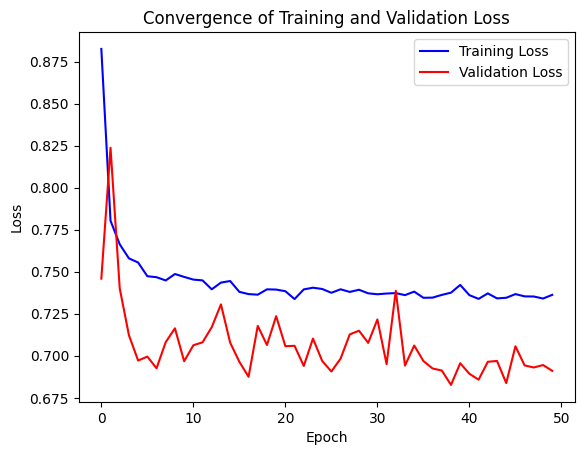

In [141]:

import torch
import torch.nn as nn
import torch.optim as optim
dropout_rate = 0.1  # You can set this to 0.1, 0.3, etc.
neuron_layer_1 = 5
neuron_layer_2 = 5
neuron_layer_3 = 5
max_iteration = 50
test_samples_size = 0.3
batch_size = 512
torch.manual_seed(42)

# Convert to PyTorch tensors
X_train_torch = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_torch = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_torch  = torch.tensor(X_val, dtype=torch.float32).to(device)
# For full classification
#X_all_torch   = torch.tensor(calssification_features.values, dtype=torch.float32).to(device)
X_test_torch  = torch.tensor(X_test, dtype=torch.float32).to(device)
# Define input and output dims
input_dim = X_train_torch.shape[1]
output_dim = len(np.unique(y_train))



# Model with dropout and batch normalization
model = nn.Sequential(
    nn.Linear(input_dim, neuron_layer_1),
    nn.BatchNorm1d(neuron_layer_1),
    nn.Sigmoid(),
    nn.Dropout(dropout_rate),
    nn.Linear(neuron_layer_1, neuron_layer_2),
    nn.BatchNorm1d(neuron_layer_2),
    nn.Sigmoid(),
    nn.Dropout(dropout_rate),
    nn.Linear(neuron_layer_2, neuron_layer_3),
    nn.BatchNorm1d(neuron_layer_3),
    nn.Sigmoid(),
    nn.Dropout(dropout_rate),
    nn.Linear(neuron_layer_3, output_dim)
).to(device)
#model=nn.Sequential(nn.Linear(input_dim, 15), nn.ReLU(), nn.Linear(15, output_dim)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()


# Training loop
# Training loop
loss_history = []
val_loss_history = []

for epoch in range(max_iteration):
    model.train()
    perm = torch.randperm(X_train_torch.shape[0])
    running_loss = 0
    num_batches = 0
    for i in range(0, X_train_torch.shape[0], batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train_torch[idx]
        yb = y_train_torch[idx].long()  # ensure long type
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        num_batches += 1
    avg_loss = running_loss / num_batches
    loss_history.append(avg_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        y_val_torch = torch.tensor(y_val, dtype=torch.long).to(device)
        val_out = model(X_val_torch)
        val_loss = criterion(val_out, y_val_torch)
        val_loss_history.append(val_loss.item())
    print(f"Epoch {epoch+1}/{max_iteration}, Train Loss: {avg_loss:.4f}, Val Loss: {val_loss.item():.4f}")



plt.figure()
plt.plot(loss_history, label='Training Loss', color="b")
plt.plot(val_loss_history, label='Validation Loss',color='r')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Convergence of Training and Validation Loss')
plt.legend()
plt.show()




In [142]:


model.eval()
from sklearn.metrics import f1_score, cohen_kappa_score

with torch.no_grad():
  train_out = model(X_train_torch)
  train_labels = train_out.argmax(dim=1).cpu().numpy()  # shape: (N,)

  test_out = model(X_test_torch)
  test_labels = test_out.argmax(dim=1).cpu().numpy()

train_f1 = f1_score(y_train, train_labels, average='macro')
test_f1 = f1_score(y_test, test_labels, average='macro')
train_kappa = cohen_kappa_score(y_train, train_labels)
test_kappa = cohen_kappa_score(y_test, test_labels)
print("Train Stat: ", train_f1, train_kappa)
print("Test Stat: ", test_f1, test_kappa)


Train Stat:  0.5409568341746511 0.5639592612601801
Test Stat:  0.3453365991214121 0.2255788684814658


# ========== Save Classified Point Cloud ==========

Classified point cloud was saved successfully.
------------ processing time =  283 seconds ------------
End.
------------ processing time =  283 seconds ------------


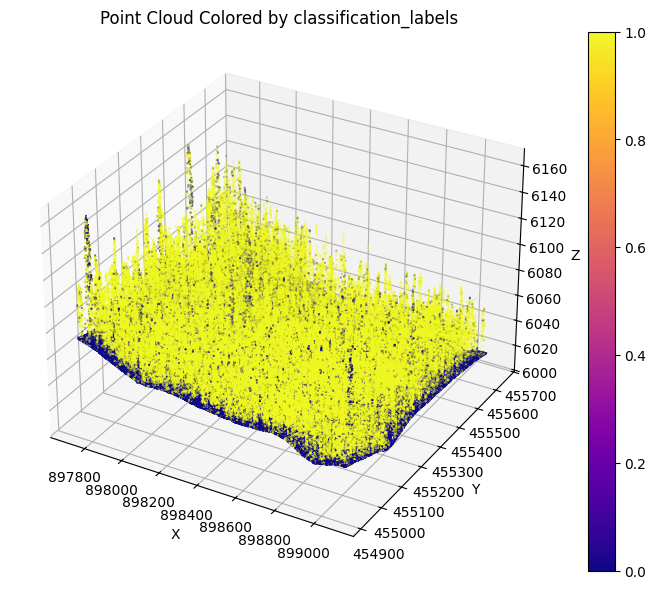

In [ ]:
# ========== Save Classified Point Cloud ==========
my_point_cloud = add_dimension(my_point_cloud, 'Class_Label', 'int')
my_point_cloud.Class_Label = all_labels

if library_option == "sklearn":
    filename = 'Output\\' + clf.__class__.__name__ + '_Classified_point_cloud.las'
else:
    filename = 'Output\\PyTorch_Classified_point_cloud.las'

# my_point_cloud.write(filename)  # Commented to prevent file output in Colab
print("Classified point cloud was saved successfully.")
print(dash_line, 'processing time = ', int(time.perf_counter() - start_time), 'seconds', dash_line)

# ========== Final Visualization ==========
print("End.")
print(dash_line, 'processing time = ', int(time.perf_counter() - start_time), 'seconds', dash_line)

# NOTE: open3d.visualization.draw() is not supported in Google Colab due to the lack of GUI support.
# Instead, we use a static 3D plot with matplotlib.

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_point_cloud_matplotlib(df, scaler_name):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    p = ax.scatter(df['x'], df['y'], df['z'], c=df[scaler_name], cmap='plasma', s=0.1)
    fig.colorbar(p)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.title(f'Point Cloud Colored by {scaler_name}')
    plt.show()

# Call the modified visualization function
visualize_point_cloud_matplotlib(point_cloud_data_frame, 'classification_labels')
